<a href="https://colab.research.google.com/github/sanju492/exit-exam/blob/main/CLUSTERING_USIN_MECHINE_LEARNING.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [4]:
# STEP 1 - Import Libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.cluster import AgglomerativeClustering
from sklearn.cluster import DBSCAN

from sklearn.metrics import silhouette_score

In [5]:
#step 2 load data set
df = pd.read_csv("/content/Wine_clust.csv")

In [6]:
#display data set
print("First 5 Rows")
display(df.head())

print("Dataset Shape :", df.shape)

First 5 Rows


,Alcohol,Malic_Acid,Ash,Ash_Alcanity,Magnesium,Total_Phenols,Flavanoids,Nonflavanoid_Phenols,Proanthocyanins,Color_Intensity,Hue,OD280,Proline
0,14.23,1.71,2.43,15.6,127,2.80,3.06,0.28,2.29,5.64,1.04,3.92,1065
1,13.20,1.78,2.14,11.2,100,2.65,2.76,0.26,1.28,4.38,1.05,3.40,1050
2,13.16,2.36,2.67,18.6,101,2.80,3.24,0.30,2.81,5.68,1.03,3.17,1185
3,14.37,1.95,2.50,16.8,113,3.85,3.49,0.24,2.18,7.80,0.86,3.45,1480
4,13.24,2.59,2.87,21.0,118,2.80,2.69,0.39,1.82,4.32,1.04,2.93,735


Dataset Shape : (178, 13)


In [7]:
#3 check missing values
print("Missing Values")
print(df.isnull().sum())


Missing Values
Alcohol                 0
Malic_Acid              0
Ash                     0
Ash_Alcanity            0
Magnesium               0
Total_Phenols           0
Flavanoids              0
Nonflavanoid_Phenols    0
Proanthocyanins         0
Color_Intensity         0
Hue                     0
OD280                   0
Proline                 0
dtype: int64


In [8]:
#4 select numerical columns
X = df.select_dtypes(include=np.number)

print("Numerical Columns")
display(X.head())


Numerical Columns


,Alcohol,Malic_Acid,Ash,Ash_Alcanity,Magnesium,Total_Phenols,Flavanoids,Nonflavanoid_Phenols,Proanthocyanins,Color_Intensity,Hue,OD280,Proline
0,14.23,1.71,2.43,15.6,127,2.80,3.06,0.28,2.29,5.64,1.04,3.92,1065
1,13.20,1.78,2.14,11.2,100,2.65,2.76,0.26,1.28,4.38,1.05,3.40,1050
2,13.16,2.36,2.67,18.6,101,2.80,3.24,0.30,2.81,5.68,1.03,3.17,1185
3,14.37,1.95,2.50,16.8,113,3.85,3.49,0.24,2.18,7.80,0.86,3.45,1480
4,13.24,2.59,2.87,21.0,118,2.80,2.69,0.39,1.82,4.32,1.04,2.93,735


In [9]:
#5 feature scaling
scaler = StandardScaler()

X_scaled = scaler.fit_transform(X)

print("Data Scaling Completed")

Data Scaling Completed


In [10]:
#6 KMEANS clustering
wcss = []

for i in range(1,11):

    kmeans = KMeans(n_clusters=i,
                    init='k-means++',
                    random_state=42)

    kmeans.fit(X_scaled)

    wcss.append(kmeans.inertia_)

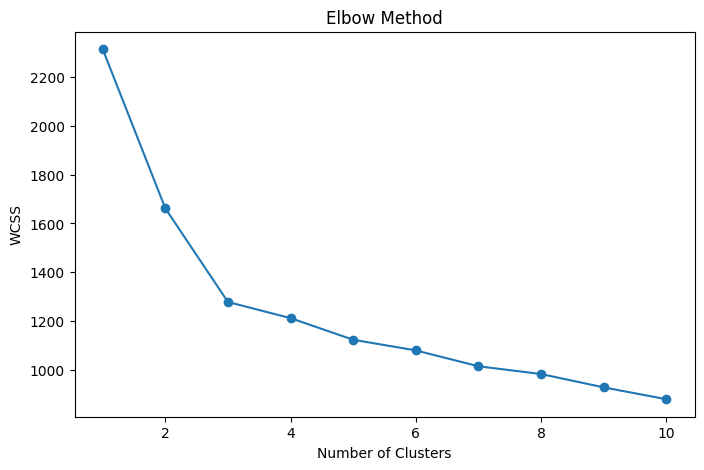

In [11]:
#elbow method graph
plt.figure(figsize=(8,5))

plt.plot(range(1,11), wcss, marker='o')

plt.title("Elbow Method")
plt.xlabel("Number of Clusters")
plt.ylabel("WCSS")

plt.show()


In [12]:
#8 silhouette score for kmeans
for i in range(2,11):

    kmeans = KMeans(n_clusters=i,
                    init='k-means++',
                    random_state=42)

    labels = kmeans.fit_predict(X_scaled)

    score = silhouette_score(X_scaled, labels)

    print("Clusters =", i, "Silhouette Score =", score)


Clusters = 2 Silhouette Score = 0.2650328591008738
Clusters = 3 Silhouette Score = 0.2848589191898987
Clusters = 4 Silhouette Score = 0.25422758316007776
Clusters = 5 Silhouette Score = 0.18362105107698137
Clusters = 6 Silhouette Score = 0.16899191019013057
Clusters = 7 Silhouette Score = 0.1726015561094921
Clusters = 8 Silhouette Score = 0.16250411307671142
Clusters = 9 Silhouette Score = 0.1738739334545086
Clusters = 10 Silhouette Score = 0.13956723664297546


In [13]:
#9 final kmeans model
kmeans_final = KMeans(n_clusters=3,
                      init='k-means++',
                      random_state=42)

df['KMeans_Cluster'] = kmeans_final.fit_predict(X_scaled)

print("KMeans Clustering Output")
display(df.head())


KMeans Clustering Output


,Alcohol,Malic_Acid,Ash,Ash_Alcanity,Magnesium,Total_Phenols,Flavanoids,Nonflavanoid_Phenols,Proanthocyanins,Color_Intensity,Hue,OD280,Proline,KMeans_Cluster
0,14.23,1.71,2.43,15.6,127,2.80,3.06,0.28,2.29,5.64,1.04,3.92,1065,2
1,13.20,1.78,2.14,11.2,100,2.65,2.76,0.26,1.28,4.38,1.05,3.40,1050,2
2,13.16,2.36,2.67,18.6,101,2.80,3.24,0.30,2.81,5.68,1.03,3.17,1185,2
3,14.37,1.95,2.50,16.8,113,3.85,3.49,0.24,2.18,7.80,0.86,3.45,1480,2
4,13.24,2.59,2.87,21.0,118,2.80,2.69,0.39,1.82,4.32,1.04,2.93,735,2


In [14]:
#10 hierarchial clustering
silhouette_scores = []

for i in range(2,11):

    hc = AgglomerativeClustering(n_clusters=i)

    labels = hc.fit_predict(X_scaled)

    score = silhouette_score(X_scaled, labels)

    silhouette_scores.append(score)

    print("Clusters =", i, "Silhouette Score =", score)

Clusters = 2 Silhouette Score = 0.2670131771272231
Clusters = 3 Silhouette Score = 0.2774439826952265
Clusters = 4 Silhouette Score = 0.225836659334758
Clusters = 5 Silhouette Score = 0.18674235566758707
Clusters = 6 Silhouette Score = 0.17966642854438503
Clusters = 7 Silhouette Score = 0.18685342560226942
Clusters = 8 Silhouette Score = 0.18834697102837825
Clusters = 9 Silhouette Score = 0.1917169293227209
Clusters = 10 Silhouette Score = 0.19856750165505588


In [15]:
#11  Final Hierarchical Model
hc_final = AgglomerativeClustering(n_clusters=3)

df['Hierarchical_Cluster'] = hc_final.fit_predict(X_scaled)

print("Hierarchical Clustering Output")
display(df.head())

Hierarchical Clustering Output


,Alcohol,Malic_Acid,Ash,Ash_Alcanity,Magnesium,Total_Phenols,Flavanoids,Nonflavanoid_Phenols,Proanthocyanins,Color_Intensity,Hue,OD280,Proline,KMeans_Cluster,Hierarchical_Cluster
0,14.23,1.71,2.43,15.6,127,2.80,3.06,0.28,2.29,5.64,1.04,3.92,1065,2,2
1,13.20,1.78,2.14,11.2,100,2.65,2.76,0.26,1.28,4.38,1.05,3.40,1050,2,2
2,13.16,2.36,2.67,18.6,101,2.80,3.24,0.30,2.81,5.68,1.03,3.17,1185,2,2
3,14.37,1.95,2.50,16.8,113,3.85,3.49,0.24,2.18,7.80,0.86,3.45,1480,2,2
4,13.24,2.59,2.87,21.0,118,2.80,2.69,0.39,1.82,4.32,1.04,2.93,735,2,2


In [16]:
#12 dbscan clustering
dbscan = DBSCAN(eps=0.5, min_samples=5)

df['DBSCAN_Cluster'] = dbscan.fit_predict(X_scaled)

print("DBSCAN Clustering Output")
display(df.head())

DBSCAN Clustering Output


,Alcohol,Malic_Acid,Ash,Ash_Alcanity,Magnesium,Total_Phenols,Flavanoids,Nonflavanoid_Phenols,Proanthocyanins,Color_Intensity,Hue,OD280,Proline,KMeans_Cluster,Hierarchical_Cluster,DBSCAN_Cluster
0,14.23,1.71,2.43,15.6,127,2.80,3.06,0.28,2.29,5.64,1.04,3.92,1065,2,2,-1
1,13.20,1.78,2.14,11.2,100,2.65,2.76,0.26,1.28,4.38,1.05,3.40,1050,2,2,-1
2,13.16,2.36,2.67,18.6,101,2.80,3.24,0.30,2.81,5.68,1.03,3.17,1185,2,2,-1
3,14.37,1.95,2.50,16.8,113,3.85,3.49,0.24,2.18,7.80,0.86,3.45,1480,2,2,-1
4,13.24,2.59,2.87,21.0,118,2.80,2.69,0.39,1.82,4.32,1.04,2.93,735,2,2,-1


In [17]:
#13 final data set
print("Final Dataset with Cluster Labels")
display(df.head())


Final Dataset with Cluster Labels


,Alcohol,Malic_Acid,Ash,Ash_Alcanity,Magnesium,Total_Phenols,Flavanoids,Nonflavanoid_Phenols,Proanthocyanins,Color_Intensity,Hue,OD280,Proline,KMeans_Cluster,Hierarchical_Cluster,DBSCAN_Cluster
0,14.23,1.71,2.43,15.6,127,2.80,3.06,0.28,2.29,5.64,1.04,3.92,1065,2,2,-1
1,13.20,1.78,2.14,11.2,100,2.65,2.76,0.26,1.28,4.38,1.05,3.40,1050,2,2,-1
2,13.16,2.36,2.67,18.6,101,2.80,3.24,0.30,2.81,5.68,1.03,3.17,1185,2,2,-1
3,14.37,1.95,2.50,16.8,113,3.85,3.49,0.24,2.18,7.80,0.86,3.45,1480,2,2,-1
4,13.24,2.59,2.87,21.0,118,2.80,2.69,0.39,1.82,4.32,1.04,2.93,735,2,2,-1


In [18]:
#14 save ouput CSV
df.to_csv("Cluster_Output.csv", index=False)

print("Output File Saved Successfully")


Output File Saved Successfully
